In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/ALLFLOWMETER_HIKARI2021.csv')

In [ ]:
df.head()

,Unnamed: 0,Unnamed: 0.1,uid,originh,originp,responh,responp,flow_duration,fwd_pkts_tot,bwd_pkts_tot,...,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size,traffic_category,Label
0,0,0,Cg61Jch3vdz9DBptj,103.255.15.23,13316,128.199.242.104,443,2.207588,15,14,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,29200,65160,0,Bruteforce-XML,1
1,1,1,CdRIlqLWdj35Y9vW9,103.255.15.23,13318,128.199.242.104,443,15.624266,15,14,...,1.534300e+07,1.534300e+07,1.534300e+07,1.534300e+07,0.0,29200,65160,0,Bruteforce-XML,1
2,2,2,CLzp9Khd0Y09Qkgrg,103.255.15.23,13320,128.199.242.104,443,12.203357,14,13,...,1.196814e+07,1.196814e+07,1.196814e+07,1.196814e+07,0.0,29200,65160,0,Bruteforce-XML,1
3,3,3,Cnf1YA4iLB4CSNWB88,103.255.15.23,13322,128.199.242.104,443,9.992448,14,13,...,9.759205e+06,9.759205e+06,9.759205e+06,9.759205e+06,0.0,29200,65160,0,Bruteforce-XML,1
4,4,4,C4ZKvv3fpO72EAOsJ6,103.255.15.23,13324,128.199.242.104,443,7.780611,14,14,...,7.545305e+06,7.545305e+06,7.545305e+06,7.545305e+06,0.0,29200,65160,0,Bruteforce-XML,1


In [ ]:
df.drop(['Unnamed: 0', 'Unnamed: 0.1'], axis = 1, inplace=True)

In [ ]:
df.describe()

,originp,responp,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,fwd_pkts_per_sec,bwd_pkts_per_sec,flow_pkts_per_sec,...,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size,Label
count,555278.000000,555278.000000,555278.000000,555278.000000,555278.000000,555278.000000,555278.000000,555278.000000,555278.000000,555278.000000,...,5.552780e+05,5.552780e+05,5.552780e+05,5.552780e+05,5.552780e+05,5.552780e+05,555278.000000,555278.000000,555278.000000,555278.000000
mean,38673.198034,5082.161647,9.306544,18.264091,18.892578,7.956928,15.803417,1720.704202,1674.140666,3394.844869,...,1.335883e+05,3.490637e+06,5.000630e+06,8.312942e+06,4.073219e+06,7.992576e+05,14750.725718,21005.879513,4546.872210,0.067887
std,18071.825216,12915.812900,101.802730,463.901484,469.078877,73.441224,467.349374,4994.579973,4548.503983,9316.856663,...,8.289045e+06,1.804930e+07,2.326516e+07,9.683372e+07,1.915958e+07,7.206576e+06,15003.491439,29155.406813,11069.456088,0.251552
min,21.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000
25%,28581.000000,53.000000,0.000311,1.000000,1.000000,1.000000,0.000000,4.430152,3.168143,7.624355,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000
50%,42693.500000,443.000000,0.026218,2.000000,2.000000,2.000000,2.000000,39.760205,43.938937,82.775849,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,5840.000000,0.000000,0.000000,0.000000
75%,53120.000000,443.000000,0.347231,10.000000,12.000000,3.000000,5.000000,80.376058,80.237673,160.578254,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,29200.000000,65160.000000,402.000000,0.000000
max,65535.000000,65522.000000,17393.030600,326292.000000,326827.000000,3953.000000,326822.000000,223696.213333,110376.421053,223696.213333,...,5.438463e+09,2.998038e+08,2.998038e+08,1.738680e+10,2.998038e+08,2.029962e+08,65535.000000,65535.000000,65535.000000,1.000000


In [ ]:
df_exclude_object = df.select_dtypes(exclude=['object'])

<AxesSubplot:>

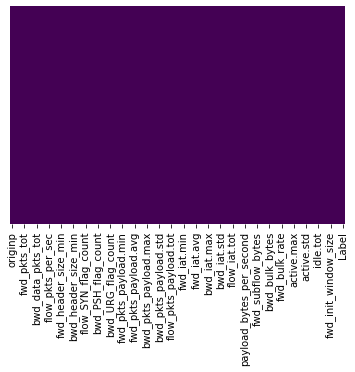

In [ ]:
sns.heatmap(df_exclude_object.isnull(), yticklabels=False, cbar=False, cmap='viridis')

In [ ]:
df_exclude_object.shape

(555278, 82)

In [ ]:
X = df_exclude_object.iloc[:,:-1]
y = df_exclude_object.iloc[:,-1]

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
#membuat feature matrix https://medium.com/data-science-365/principal-component-analysis-pca-with-scikit-learn-1e84a0c731b0
#https://towardsdatascience.com/using-principal-component-analysis-pca-for-machine-learning-b6e803f5bf1e
X_fea_mat = X.values
scaler = StandardScaler()
scaler.fit(X_fea_mat)
X_scaled = scaler.transform(X_fea_mat)

In [ ]:
from sklearn.decomposition import PCA

In [ ]:
pca_95 = PCA(n_components=0.95, random_state=2023)
pca_95.fit(X_scaled)
x_scaled_pca95 = pca_95.transform(X_scaled)


In [ ]:
# print the explained variances
print("Variances (Percentage):")
print(pca_95.explained_variance_ratio_ * 100)
print()


Variances (Percentage):
[18.34622417 11.67899366 11.50515532  7.32621064  6.05459949  5.08187904
  4.74587657  4.40828885  3.35740062  2.56714383  1.96869564  1.69647089
  1.59999428  1.51208129  1.43898741  1.3499917   1.24736369  1.22020047
  1.17309694  1.12614533  1.10477323  1.092224    1.02937841  0.90283151
  0.72863356  0.65095421  0.60195766]



Text(0, 0.5, 'Explained Variance')

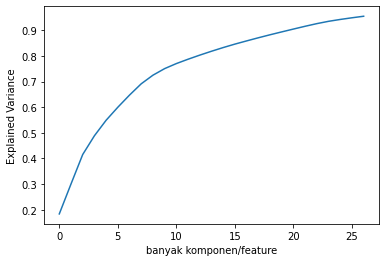

In [ ]:
# plot a scree plot
plt.plot(np.cumsum(pca_95.explained_variance_ratio_))
plt.xlabel('banyak komponen/feature')
plt.ylabel('Explained Variance')

In [ ]:
x_scaled_pca95.shape

(555278, 27)

In [ ]:
df_reducted = pd.DataFrame(x_scaled_pca95, columns = ['PC1', 'PC2', 'PC3', 'PC4', 'PC5',
                                                        'PC6', 'PC7', 'PC8', 'PC9', 'PC10',
                                                        'PC11', 'PC12', 'PC13', 'PC14', 'PC15',
                                                        'PC16', 'PC17', 'PC18', 'PC19', 'PC20',
                                                        'PC21', 'PC22', 'PC23', 'PC24', 'PC25',
                                                        'PC26', 'PC27'])

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(df_reducted, y, test_size=0.3, random_state=101)

In [ ]:
from sklearn.linear_model import LogisticRegression
logmodel = LogisticRegression(max_iter=3000)

In [ ]:
logmodel.fit(X_train, y_train)

LogisticRegression(max_iter=3000)

In [ ]:
predictions = logmodel.predict(X_test)

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.93      1.00      0.96    155457
           1       0.13      0.00      0.01     11127

    accuracy                           0.93    166584
   macro avg       0.53      0.50      0.49    166584
weighted avg       0.88      0.93      0.90    166584



In [ ]:
df.iloc[:,-1] #cuman target 'label'

0         1
1         1
2         1
3         1
4         1
         ..
555273    1
555274    1
555275    1
555276    1
555277    1
Name: Label, Length: 555278, dtype: int64

#Cari tau maksud Label

In [ ]:
df[['Label','traffic_category']]

,Label,traffic_category
0,1,Bruteforce-XML
1,1,Bruteforce-XML
2,1,Bruteforce-XML
3,1,Bruteforce-XML
4,1,Bruteforce-XML
...,...,...
555273,1,XMRIGCC CryptoMiner
555274,1,XMRIGCC CryptoMiner
555275,1,XMRIGCC CryptoMiner
555276,1,XMRIGCC CryptoMiner


In [ ]:
df.groupby(by='Label').count()['traffic_category']

Label
0    517582
1     37696
Name: traffic_category, dtype: int64

In [ ]:
df[df['Label']==0]

,uid,originh,originp,responh,responp,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,...,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size,traffic_category,Label
11029,CrROxt3DAa7vRwpvWh,103.255.15.27,54992,103.255.15.23,42000,0.000146,1,1,0,0,...,0.0,0.0,0.0,0.0,0.0,29200,0,29200,Background,0
11030,CcHgwD2KGHnvobuPE8,103.255.15.27,59242,103.255.15.23,42001,0.000223,1,1,0,0,...,0.0,0.0,0.0,0.0,0.0,29200,0,29200,Background,0
11031,CRnYqn2FTMxRBR7J87,103.255.15.27,54998,103.255.15.23,42000,0.000153,1,1,0,0,...,0.0,0.0,0.0,0.0,0.0,29200,0,29200,Background,0
11032,CeBQci3D6ZVhkvU0yi,103.255.15.20,62517,103.255.15.255,1947,0.000000,1,0,1,0,...,0.0,0.0,0.0,0.0,0.0,0,0,0,Background,0
11033,COF9LI2KzBheDjVBPk,103.255.15.20,62519,255.255.255.255,1947,0.000000,1,0,1,0,...,0.0,0.0,0.0,0.0,0.0,0,0,0,Background,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
528606,CAtfCPJ456MsGNFkf,103.255.15.150,33852,128.199.242.104,443,0.253536,9,12,3,7,...,0.0,0.0,0.0,0.0,0.0,29200,65160,402,Benign,0
528607,CqGVxG4vzCwa0dXR78,103.255.15.150,43865,8.8.8.8,53,0.024452,2,2,2,2,...,0.0,0.0,0.0,0.0,0.0,0,0,0,Benign,0
528608,C8fhiv13TK3egWlYqi,103.255.15.150,33854,128.199.242.104,443,0.258555,9,12,3,7,...,0.0,0.0,0.0,0.0,0.0,29200,65160,402,Benign,0
528609,CCzIwg4QTMcMEMfnC2,103.255.15.150,33856,128.199.242.104,443,0.244943,10,13,3,8,...,0.0,0.0,0.0,0.0,0.0,29200,65160,402,Benign,0
